# Plotting CSV Data

This notebook demonstrates how to plot CSV data using gplately. CSV (Comma-Separated Values) files are simple text files that store tabular data. CSV files are one of the most common formats for storing point data with geographic coordinates, making them perfect for plotting fossil locations, sample sites, geological observations, and other location-based scientific data.

### Setup

Let’s start by importing the required packages.

In [1]:
# Ensure you have the required packages installed:
# Run `pip install gplately pygplates cartopy geopandas matplotlib pandas numpy` if not already installed.
import gplately
from plate_model_manager import PlateModelManager
import pygplates
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

2025-09-25 10:44:24 - gplately - ERROR - Failed to import PyGMT. PyGMT requires Python>=3.11.
2025-09-25 10:44:26 - gplately - ERROR - Failed to import PyGMT. PyGMT requires Python>=3.11.


Now, let's use gplately's `PlateModelManager` to create a plate reconstruction model based on the Müller et al. (2019) global plate model, [“A Global Plate Model Including Lithospheric Deformation Along Major Rifts and Orogens Since the Triassic”](https://www.earthbyte.org/muller-et-al-2019-deforming-plate-reconstruction-and-seafloor-age-grids-tectonics/).

> `NOTE:` You can also load a plate model through local files on your system!

We then extract individual layers from the model:

- Coastlines: for reconstructing ancient shorelines.

- ContinentalPolygons: for plotting continental outlines.

- COBs (Continent-Ocean Boundaries): useful for defining the transition between land and oceanic crust.

Finally, we create a `PlotTopologies object (gplot)`, which simplifies visualizing reconstructed features like plate boundaries, continents, and COBs at any geological time.

In [2]:
pm_manager = PlateModelManager()

# Load the Muller 2019 plate model 
muller2019_model = pm_manager.get_model("Muller2019", data_dir="../../data/plate-model-repo")

# This object will allow us to reconstruct the plate boundaries at different times
model = gplately.PlateReconstruction(
    muller2019_model.get_rotation_model(),
    muller2019_model.get_topologies(),
    muller2019_model.get_static_polygons()
)

# Coastlines, Continental polygons and COBs
coastlines = muller2019_model.get_layer('Coastlines')
continents = muller2019_model.get_layer('ContinentalPolygons')
COBs = muller2019_model.get_layer('COBs')
rotation_model = muller2019_model.get_rotation_model()
static_polygons_filename = muller2019_model.get_static_polygons()

# Create PlotTopologies object
gplot = gplately.PlotTopologies(model, coastlines=coastlines, continents=continents, COBs=COBs)

time_ma = 100  # Ma (Million years ago)

### Downloading & Importing CSV Data

In this method, we will learn how to plot points from a CSV file. In this example, we import data from the [PBDB]("https://paleobiodb.org/classic/displayDownloadGenerator") using the data url straight into `pandas`. Alternatively, we can download the csv file from their website and import that. The data is of the distribution of Jurassic Foraminifera (a type of microscopic organism) over time.

> `NOTE:` When importing CSV files, it is generally easier if the first row contains column names, as this helps with automatically identifying the data fields. However, if the CSV file doesn't include headers or includes extra metadata, libraries like Pandas allow you to skip these header rows when importing the data.


In [3]:
# ---- Load the CSV point data ----
# Replace this URL with the actual URL of your CSV file
pbdb_data_url = 'https://paleobiodb.org/data1.2/occs/list.csv?datainfo&rowcount&base_name=Foraminifera&interval=Jurassic&show=coords,env'
points = pd.read_csv(pbdb_data_url, sep=',', skiprows=18)

# The CSV contains columns for latitude and longitude
longitudes = points['lng']
latitudes = points['lat']

### Plotting

We're using the `Cartopy` library to plot geological features (like continents, ridges, and subduction zones). We also use the GPlates' [`PlotTopologies` object](https://gplates.github.io/gplately/latest/sphinx/html/generated/gplately.PlotTopologies.html) to plot coastlines and other geological data at 100 Ma and place points representing the locations of Foraminifera on the map. Here's how it works:

- Set the time to present day: `gplot.time = 0` tells GPlately we want to see Earth as it looks right now (0 million years ago).
- Draw Earth's current features: We add several geological layers to build up a complete picture:
- Plot the fossil locations: The green dots show where scientists have found Jurassic foraminifera fossils in modern-day rock formations.
- Make it readable: Add a legend, title, and display the map.

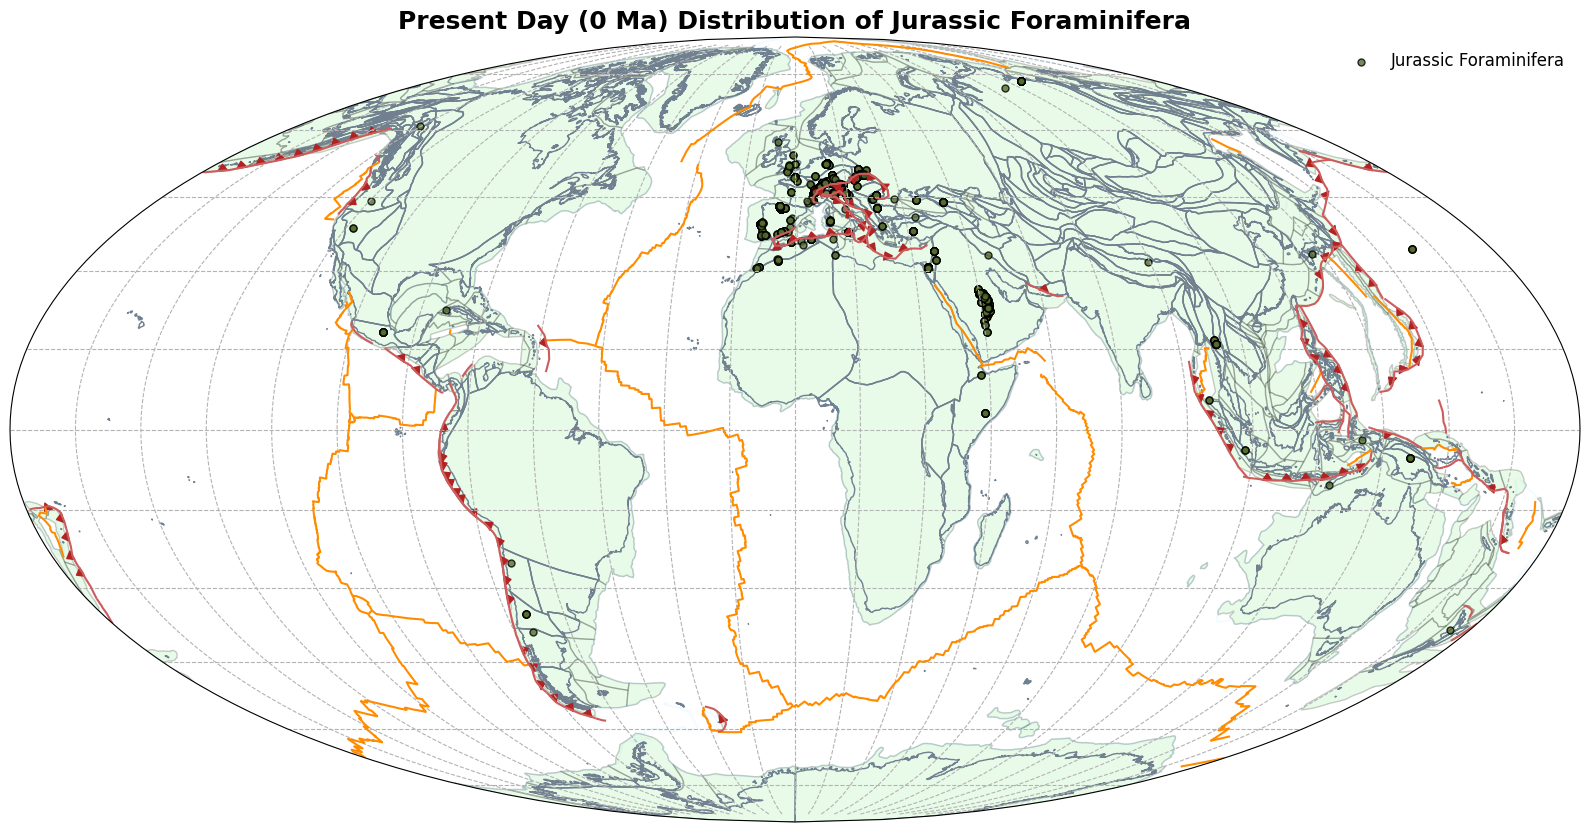

In [6]:
# --- PLOT 1: Present Day (0 Ma) ---
# Plot for Present day (0 Ma)
plt.figure(figsize=(16, 12), dpi=100)
ax = plt.subplot(111, projection=ccrs.Mollweide(central_longitude=0))
ax.set_global()
ax.gridlines(color='0.7', linestyle='--', xlocs=np.arange(-180, 180, 15), ylocs=np.arange(-90, 90, 15))
ax.set_title("Present Day (0 Ma) Distribution of Jurassic Foraminifera", fontsize=18, fontweight='bold')

# Plot shapefile features
gplot.time = 0  # Set time to present day
gplot.plot_continent_ocean_boundaries(ax, color='deepskyblue', alpha=0.05)
gplot.plot_continents(ax, facecolor='lightgreen', alpha=0.2)
gplot.plot_coastlines(ax, color='slategray')
gplot.plot_ridges(ax, color='darkorange')
gplot.plot_trenches(ax, color='indianred')
gplot.plot_subduction_teeth(ax, color='firebrick')

# Scatter plot of the points
ax.scatter(longitudes, latitudes, color='#556B2F', transform=ccrs.PlateCarree(), label='Jurassic Foraminifera', s=25, edgecolor='black', alpha=0.8)
ax.legend(frameon=False, loc='upper right', fontsize=12)
plt.tight_layout()

# Show present day plot
plt.show()

### Reconstructing & Plotting

This code creates the same type of map, but "rewinds" Earth back to how it looked 100 million years ago, moving both the geological features and the fossil locations back through time. What's happening step by step:

- Set up the same canvas: Same projection and grid as before for easy comparison.
- Set the time to 100 Ma: `gplot.time = time_ma` tells GPlately to reconstruct Earth as it appeared 100 million years ago. (This is the key difference!)
- Draw Earth's ancient features: We plot the same types of geological features, but now they're positioned where they were 100 million years ago:
- Plot the reconstructed fossil locations: The green dots now show where those fossil locations would have been 100 million years ago, accounting for how the tectonic plates have moved since then.

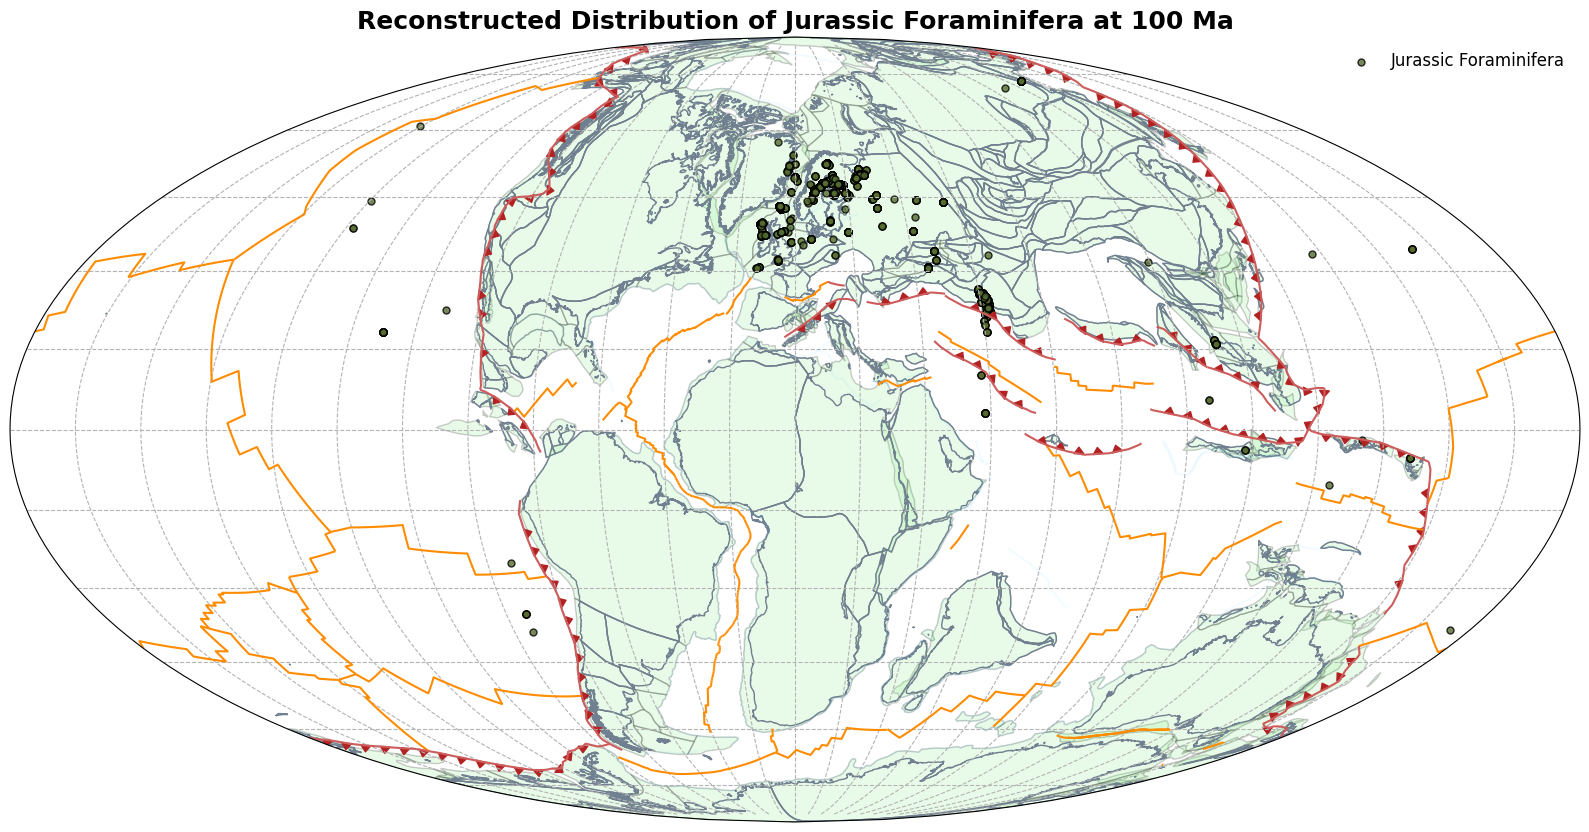

In [5]:
# ---- PLOT 2: Reconstructed to 100 Ma ----
plt.figure(figsize=(16, 12), dpi=100)
ax = plt.subplot(111, projection=ccrs.Mollweide(central_longitude=0))
ax.set_global()
ax.gridlines(color='0.7', linestyle='--', xlocs=np.arange(-180, 180, 15), ylocs=np.arange(-90, 90, 15))
ax.set_title("Reconstructed Distribution of Jurassic Foraminifera at 100 Ma", fontsize=18, fontweight='bold')

# Plot shapefile features
gplot.time = time_ma  # Set time to 100 Ma (from setup above)
gplot.plot_continent_ocean_boundaries(ax, color='deepskyblue', alpha=0.05)
gplot.plot_continents(ax, facecolor='lightgreen', alpha=0.2)
gplot.plot_coastlines(ax, color='slategray')
gplot.plot_ridges(ax, color='darkorange')
gplot.plot_trenches(ax, color='indianred')
gplot.plot_subduction_teeth(ax, color='firebrick')

# Scatter plot of the points for 100 Ma (reconstructed positions)
ax.scatter(longitudes, latitudes, color='#556B2F', transform=ccrs.PlateCarree(), label='Jurassic Foraminifera', s=25, edgecolor='black', alpha=0.8)
ax.legend(frameon=False, loc='upper right', fontsize=12)
plt.tight_layout()

# Show reconstructed plot for 100 Ma
plt.show()